In [ ]:
from transformers import pipeline

# clf = pipeline(
#     "text-classification",
#     model="cardiffnlp/twitter-roberta-base-sentiment-latest",
#     device=-1,
#     model_kwargs={"torch_dtype": None}
# )

c:\Users\yasmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
c:\Users\yasmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\yasmi\.cache\huggingface\hub\models--cardiffnlp--twitter-roberta-base-sentiment-latest. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggi

In [ ]:
# print(clf("This car is amazing, way better than the BMW"))

[{'label': 'positive', 'score': 0.982631504535675}]


In [3]:
clf_local = pipeline(
    "text-classification",
    model="sota_model/",
    tokenizer="sota_model/",
    device=-1
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7743.19it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: sota_model/
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
print(clf_local("This car is amazing, way better than the BMW"))

[{'label': 'positive', 'score': 0.982631504535675}]


In [8]:
import pandas as pd
df = pd.read_csv("../data/scheme3/cleaned_comments3.csv")
X = df["clean_comment"]
y = df["majority_vote_final"]
y = y.replace({"negtaive": "negative"})
y = y.str.lower()

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
idx = np.arange(len(X))

_, X_test, _, y_test, _, idx_test = train_test_split( X, y, idx, test_size=0.2, random_state=42, stratify=y)

In [14]:
print(type(X_test.iloc[0]))
print(X_test.iloc[0])

<class 'str'>
reliability choose mercedes benz neighbor still driving 77 benz 240 diesel 24 years old 01 clk430 still running smooth 230k miles odo 21 gla45 bought fantastic


In [16]:
for i, x in enumerate(X_test):
    if not isinstance(x, str):
        print(i, type(x), x)
        break
    
X_test = X_test.fillna("").astype(str)

101 <class 'float'> nan


In [17]:
preds = clf_local(list(X_test))
preds = [p["label"] for p in preds]

In [20]:
set(preds)

{'negative', 'neutral', 'positive'}

no mapping needed, their outputs match

In [48]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

print("SOTA RESULTS")
print(classification_report(y_test, preds))

f1 = f1_score(y_test, preds, average="macro")
acc = accuracy_score(y_test, preds)

print("F1:", f1)
print("Accuracy:", acc)

cm = confusion_matrix(y_test, preds)
print("Confusion Matrix:\n", cm)

SOTA RESULTS
              precision    recall  f1-score   support

    negative       0.48      0.57      0.52        37
     neutral       0.72      0.79      0.75       103
    positive       0.80      0.57      0.67        61

    accuracy                           0.68       201
   macro avg       0.66      0.64      0.65       201
weighted avg       0.70      0.68      0.68       201

F1: 0.6450617283950617
Accuracy: 0.681592039800995
Confusion Matrix:
 [[21 16  0]
 [13 81  9]
 [10 16 35]]


In [ ]:
import joblib
from sklearn.feature_extraction.text import CountVectorizer
model = joblib.load("../BEST_MODEL_F1_trial.pkl")
classes = list(model.classes_)
print("MODEL CLASSES ORDER:", classes)


VOCAB_PATH = "../representations/scheme3_vocab.txt"

with open(VOCAB_PATH, "r", encoding="utf-8") as f:
    vocab = [line.strip() for line in f]

vectorizer = CountVectorizer(vocabulary=vocab)

MODEL CLASSES ORDER: ['negative', 'neutral', 'positive']


In [26]:
X_vec = vectorizer.transform(X_test)
y_pred_svc = model.predict(X_vec)

c:\Users\yasmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


weighted generally gives more "flattering" results going up to ~73%, but nevertheless, the comparison used macro f1

In [50]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score

labels = ["negative", "neutral", "positive"]

print(classification_report(y_test, y_pred_svc, labels=labels))

print("F1:", f1_score(y_test, y_pred_svc, average="weighted"))
print("Accuracy:", accuracy_score(y_test, y_pred_svc))

cm = confusion_matrix(y_test, y_pred_svc, labels=labels)
print(cm)

              precision    recall  f1-score   support

    negative       0.65      0.35      0.46        37
     neutral       0.75      0.92      0.83       103
    positive       0.78      0.69      0.73        61

    accuracy                           0.75       201
   macro avg       0.73      0.65      0.67       201
weighted avg       0.74      0.75      0.73       201

F1: 0.7289585633996303
Accuracy: 0.746268656716418
[[13 17  7]
 [ 3 95  5]
 [ 4 15 42]]


In [51]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score

labels = ["negative", "neutral", "positive"]

print(classification_report(y_test, y_pred_svc, labels=labels))

print("F1:", f1_score(y_test, y_pred_svc, average="macro"))
print("Accuracy:", accuracy_score(y_test, y_pred_svc))

cm = confusion_matrix(y_test, y_pred_svc, labels=labels)
print(cm)

              precision    recall  f1-score   support

    negative       0.65      0.35      0.46        37
     neutral       0.75      0.92      0.83       103
    positive       0.78      0.69      0.73        61

    accuracy                           0.75       201
   macro avg       0.73      0.65      0.67       201
weighted avg       0.74      0.75      0.73       201

F1: 0.670887363335876
Accuracy: 0.746268656716418
[[13 17  7]
 [ 3 95  5]
 [ 4 15 42]]


comparison: 
<h4> SOTA model: </h4>
<p>___________________precision_____recall_____f1-score___support

    negative       0.48      0.57      0.52        37
    neutral        0.72      0.79      0.75       103
    positive       0.80      0.57      0.67        61
    
    accuracy                           0.68       201
    macro avg       0.66      0.64     0.65       201
    weighted avg    0.70      0.68     0.68       201

F1: 0.6450617283950617</br>
Accuracy: 0.681592039800995</br>
Confusion Matrix:
 [[21 16  0]</br>
 [13 81  9]</br>
 [10 16 35]]</p>

<h4> Linear SVC </h4>
<p>___________________precision_____recall_____f1-score___support

    negative       0.65      0.35      0.46        37
     neutral       0.75      0.92      0.83       103
    positive       0.78      0.69      0.73        61

    accuracy                           0.75       201
    macro avg       0.73      0.65     0.67       201
    weighted avg    0.74      0.75     0.73       201

F1: 0.670887363335876</br>
Accuracy: 0.746268656716418</br>
[[13 17  7]</br>
 [ 3 95  5]</br>
 [ 4 15 42]]</p>

helper methods from task2

In [28]:
def extract_car_model(text):
    if not isinstance(text, str):
        return str(text)
    match = re.search(
        r'\b(Tesla|Nissan|Skoda|Rivian|Chevy|Ford|Lucid|Volkswagen|Toyota|Sentra|BMW|ID Buzz|Hyundai|Mustang|Kia|Volvo|Audi|Lexus|Jeep|Porsche|Mazda|Mercedes|Range Rover|Renault)\b',
        text, re.IGNORECASE)
    return match.group(0) if match else "Other"

def extract_topic(text):
    if not isinstance(text, str):
        return str(text)
    topics = ['battery', 'range', 'price', 'charging', 'autopilot', 'design', 'performance', 'reliability', 'fuel']
    for t in topics:
        if re.search(rf'\b{t}\b', text, re.IGNORECASE):
            return t
    return "Other"

In [30]:
import re
df["car_model"] = df["clean_comment"].apply(extract_car_model)

In [31]:
df["topic"] = df["clean_comment"].apply(extract_topic)

the svc model expects bow vectorized data

In [33]:
df["clean_comment"] = df["clean_comment"].fillna("").astype(str)
X_vec = vectorizer.transform(df["clean_comment"])

at the same time, running prediction on the entire dataset using the svc model (so this doesn't apply to the sota model) feels</br>
disingenuous, because the model already see this data and trained on it, but regardless, we already compared between them fair and </br>
square up there using the test set that the svc model hasn't seen yet

In [34]:
df["svc_pred"] = model.predict(X_vec)

c:\Users\yasmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


In [ ]:
df["sota_pred"] = clf_local(list(df["clean_comment"]))

In [38]:
df["sota_pred"] = [p["label"] for p in df["sota_pred"]]

In [52]:
print("SVC FULL DATASET")
print("Acc:", accuracy_score(df["majority_vote_final"], df["svc_pred"]))
print("F1:", f1_score(df["majority_vote_final"], df["svc_pred"], average="macro"))

print("SOTA FULL DATASET")
print("Acc:", accuracy_score(df["majority_vote_final"], df["sota_pred"]))
print("F1:", f1_score(df["majority_vote_final"], df["sota_pred"], average="macro"))

SVC FULL DATASET
Acc: 0.9452191235059761
F1: 0.702605207580332
SOTA FULL DATASET
Acc: 0.7270916334661355
F1: 0.5234182938691467


In [53]:
def evaluate_group(data, pred_col):
    return pd.Series({
        "accuracy": accuracy_score(data["majority_vote_final"], data[pred_col]),
        "f1": f1_score(data["majority_vote_final"], data[pred_col], average="weighted")
    })

In [54]:
topic_report_svc = df.groupby("topic").apply(lambda x: evaluate_group(x, "svc_pred"))
topic_report_sota = df.groupby("topic").apply(lambda x: evaluate_group(x, "sota_pred"))

C:\Users\yasmi\AppData\Local\Temp\ipykernel_11664\201719585.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  topic_report_svc = df.groupby("topic").apply(lambda x: evaluate_group(x, "svc_pred"))
C:\Users\yasmi\AppData\Local\Temp\ipykernel_11664\201719585.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  topic_report_sota = df.groupby("topic").apply(lambda x: evaluate_group(x, "sota_pred"))


In [55]:
comparison = pd.concat(
    [
        topic_report_svc.add_prefix("svc_"),
        topic_report_sota.add_prefix("sota_")
    ],
    axis=1
)

print(comparison)

             svc_accuracy    svc_f1  sota_accuracy   sota_f1
topic                                                       
Other            0.946237  0.945251       0.734409  0.733238
battery          1.000000  1.000000       1.000000  1.000000
design           0.750000  0.766667       0.500000  0.500000
fuel             1.000000  1.000000       1.000000  1.000000
nan              1.000000  1.000000       0.000000  0.000000
performance      1.000000  1.000000       0.875000  0.859848
price            0.850000  0.859139       0.450000  0.451946
range            1.000000  1.000000       0.888889  0.855253
reliability      0.800000  0.786667       0.600000  0.600000


In [56]:
car_report_svc = df.groupby("car_model").apply(lambda x: evaluate_group(x, "svc_pred"))
car_report_sota = df.groupby("car_model").apply(lambda x: evaluate_group(x, "sota_pred"))
comparison_car = pd.concat(
    [
        car_report_svc.add_prefix("svc_"),
        car_report_sota.add_prefix("sota_")
    ],
    axis=1
)

print(comparison_car)

C:\Users\yasmi\AppData\Local\Temp\ipykernel_11664\2914801416.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  car_report_svc = df.groupby("car_model").apply(lambda x: evaluate_group(x, "svc_pred"))


             svc_accuracy    svc_f1  sota_accuracy   sota_f1
car_model                                                   
Other            0.946593  0.945892       0.738490  0.738340
audi             0.900000  0.898680       0.650000  0.652652
bmw              0.966667  0.963397       0.660000  0.656797
ford             1.000000  1.000000       1.000000  1.000000
kia              1.000000  1.000000       0.500000  0.500000
lexus            0.960000  0.956488       0.880000  0.869463
lucid            1.000000  1.000000       1.000000  1.000000
mazda            1.000000  1.000000       1.000000  1.000000
mercedes         0.918367  0.918135       0.755102  0.758006
nan              1.000000  1.000000       0.000000  0.000000
nissan           1.000000  1.000000       0.000000  0.000000
porsche          0.935484  0.934759       0.741935  0.759188
range rover      1.000000  1.000000       1.000000  1.000000
skoda            1.000000  1.000000       1.000000  1.000000
tesla            1.00000

C:\Users\yasmi\AppData\Local\Temp\ipykernel_11664\2914801416.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  car_report_sota = df.groupby("car_model").apply(lambda x: evaluate_group(x, "sota_pred"))


In [57]:
with open("../results/final_report_topic.txt", "w", encoding="utf-8") as f:
    f.write(str(comparison))

In [58]:
with open("../results/final_report_car.txt", "w", encoding="utf-8") as f:
    f.write(str(comparison_car))

"other" by far triumphs over any other topics and any other car model, so there will be versions where it is excluded

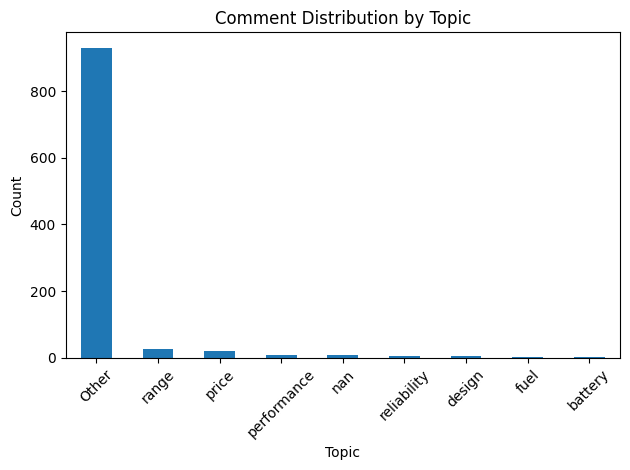

In [ ]:
import matplotlib.pyplot as plt

df["topic"].value_counts().plot(kind="bar")
plt.title("Comment Distribution by Topic")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("topic_distribution.png")
plt.show()

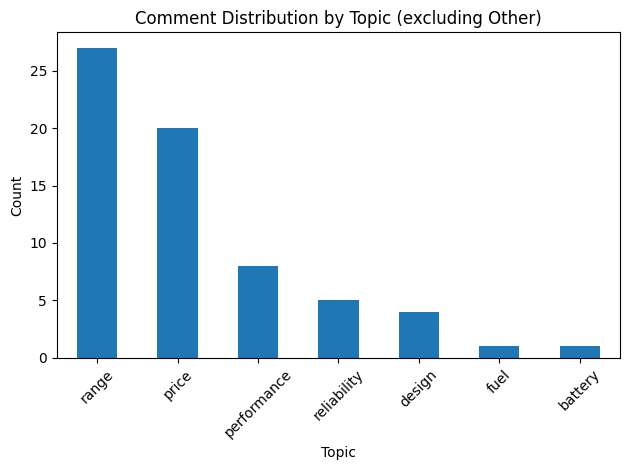

In [85]:
filtered = df[~df["topic"].isin(["Other", "nan"])]

filtered["topic"].value_counts().plot(kind="bar")

plt.title("Comment Distribution by Topic (excluding Other)")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("topic_distribution_no_other.png")
plt.show()

it seems that people mostly mention price/range when it comes to cars

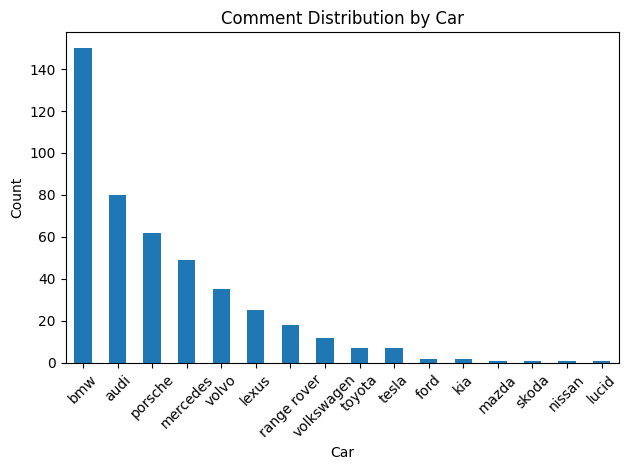

In [89]:
filtered = df[~df["car_model"].isin(["Other", "nan"])]

filtered["car_model"].value_counts().plot(kind="bar")

plt.title("Comment Distribution by Car")
plt.xlabel("Car")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("car_distribution_no_other.png")
plt.show()

also clearly, bmw is, by far, a fan-favorite

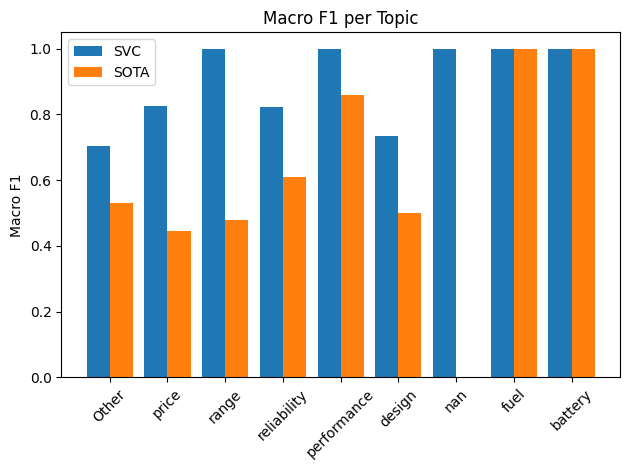

In [61]:
import numpy as np
topics = df["topic"].unique()

svc_f1 = []
sota_f1 = []

for t in topics:
    subset = df[df["topic"] == t]
    
    svc_f1.append(f1_score(subset["majority_vote_final"], subset["svc_pred"], average="macro"))
    sota_f1.append(f1_score(subset["majority_vote_final"], subset["sota_pred"], average="macro"))
    


x = np.arange(len(topics))

plt.bar(x - 0.2, svc_f1, width=0.4, label="SVC")
plt.bar(x + 0.2, sota_f1, width=0.4, label="SOTA")

plt.xticks(x, topics, rotation=45)
plt.title("Macro F1 per Topic")
plt.ylabel("Macro F1")
plt.legend()

plt.tight_layout()
plt.savefig("f1_per_topic.png")
plt.show()

SVC may look like it's doing better, but let's not forget that it has already seen most of these data in the training, still, the fact that sota is catching up in battery, fuel and performance topics is pretty good

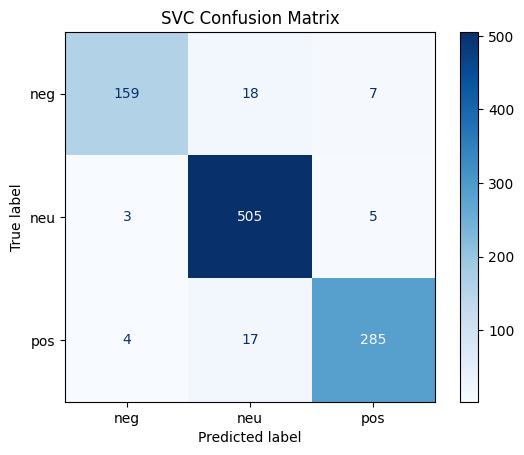

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(df["majority_vote_final"], df["svc_pred"], labels=["negative","neutral","positive"])

disp = ConfusionMatrixDisplay(cm, display_labels=["neg","neu","pos"])
disp.plot(cmap="Blues")

plt.title("SVC Confusion Matrix")
plt.savefig("svc_confusion_matrix.png")
plt.show()

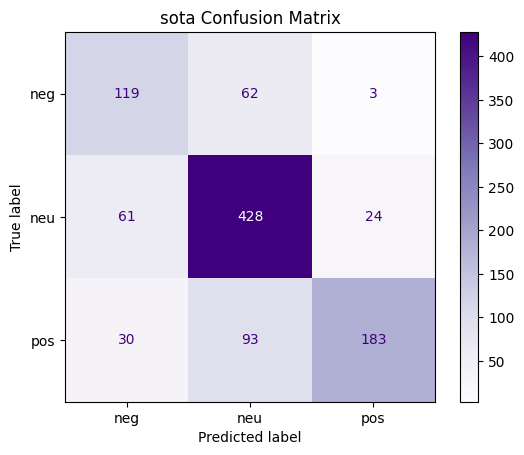

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(df["majority_vote_final"], df["sota_pred"], labels=["negative","neutral","positive"])

disp = ConfusionMatrixDisplay(cm, display_labels=["neg","neu","pos"])
disp.plot(cmap="Purples")

plt.title("sota Confusion Matrix")
plt.savefig("sota_confusion_matrix.png")
plt.show()

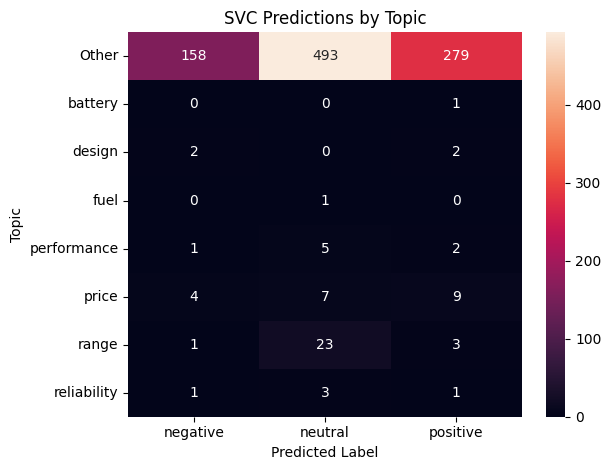

In [80]:
import seaborn as sns
filtered_df = df[
    (df["topic"] != "nan")
]

pivot = pd.crosstab(filtered_df["topic"], filtered_df["svc_pred"])

sns.heatmap(pivot, annot=True, fmt="d")
plt.title("SVC Predictions by Topic")
plt.xlabel("Predicted Label")
plt.ylabel("Topic")
plt.tight_layout()
plt.savefig("svc_topic_heatmap.png")
plt.show()

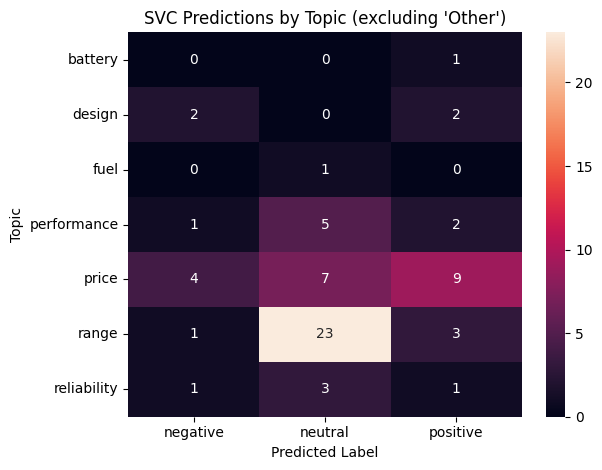

In [77]:
filtered_df = df[
    (df["topic"] != "Other") &
    (df["topic"] != "nan")
]

pivot = pd.crosstab(filtered_df["topic"], filtered_df["svc_pred"])

sns.heatmap(pivot, annot=True, fmt="d")

plt.title("SVC Predictions by Topic (excluding 'Other')")
plt.xlabel("Predicted Label")
plt.ylabel("Topic")

plt.tight_layout()
plt.savefig("svc_topic_heatmap_no_other.png")
plt.show()

clearly, the "neutral" class greatly over-powers other classes which is a problem

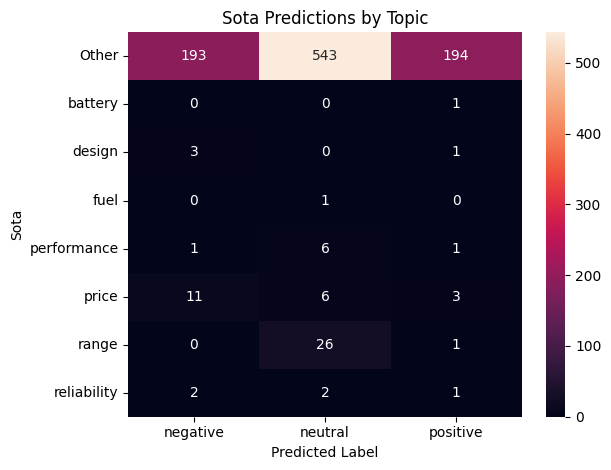

In [79]:
import seaborn as sns

filtered_df = df[
    (df["topic"] != "nan")
]

pivot = pd.crosstab(filtered_df["topic"], filtered_df["sota_pred"])

sns.heatmap(pivot, annot=True, fmt="d")
plt.title("Sota Predictions by Topic")
plt.xlabel("Predicted Label")
plt.ylabel("Sota")
plt.tight_layout()
plt.savefig("sota_topic_heatmap.png")
plt.show()

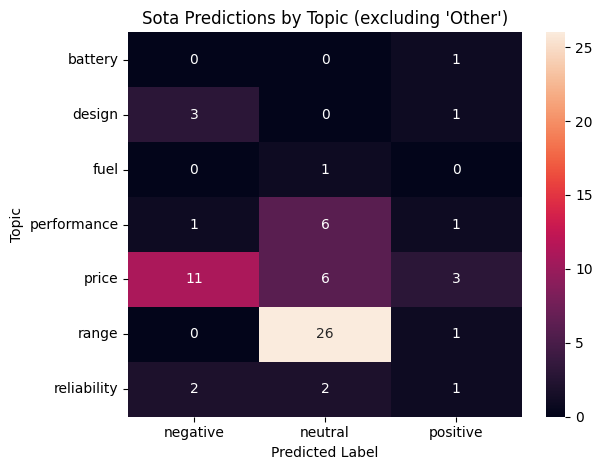

In [78]:
filtered_df = df[
    (df["topic"] != "Other") &
    (df["topic"] != "nan")
]

pivot = pd.crosstab(filtered_df["topic"], filtered_df["sota_pred"])

sns.heatmap(pivot, annot=True, fmt="d")

plt.title("Sota Predictions by Topic (excluding 'Other')")
plt.xlabel("Predicted Label")
plt.ylabel("Topic")

plt.tight_layout()
plt.savefig("sota_topic_heatmap_no_other.png")
plt.show()

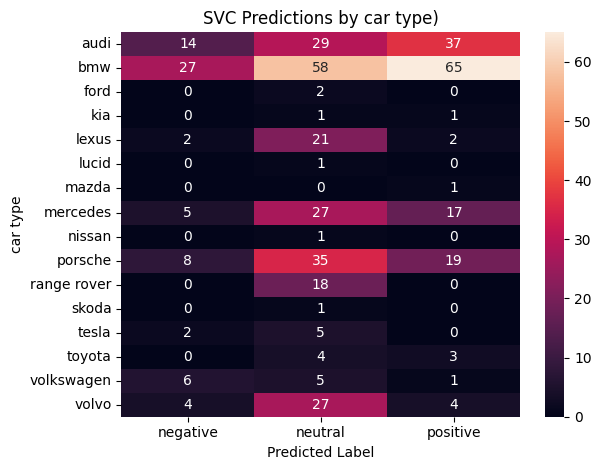

In [82]:
filtered_df = df[
    (df["car_model"] != "Other") &
    (df["car_model"] != "nan")
]

pivot = pd.crosstab(filtered_df["car_model"], filtered_df["svc_pred"])

sns.heatmap(pivot, annot=True, fmt="d")

plt.title("SVC Predictions by car type)")
plt.xlabel("Predicted Label")
plt.ylabel("car type")

plt.tight_layout()
plt.savefig("svc_car_heatmap_no_other.png")
plt.show()

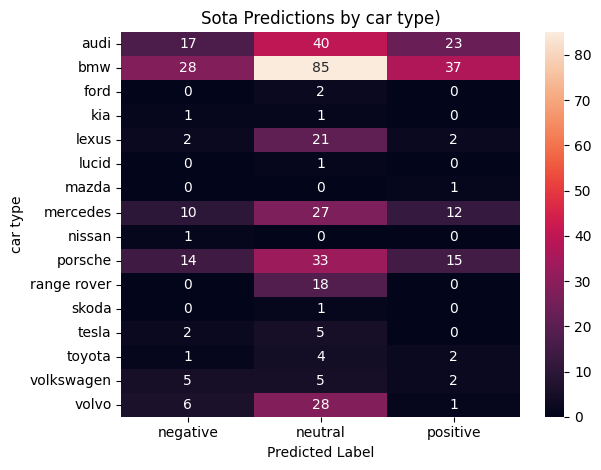

In [83]:
filtered_df = df[
    (df["car_model"] != "Other") &
    (df["car_model"] != "nan")
]

pivot = pd.crosstab(filtered_df["car_model"], filtered_df["sota_pred"])

sns.heatmap(pivot, annot=True, fmt="d")

plt.title("Sota Predictions by car type)")
plt.xlabel("Predicted Label")
plt.ylabel("car type")

plt.tight_layout()
plt.savefig("sota_car_heatmap_no_other.png")
plt.show()